In [1]:
# ============================================================
# FUNCTION 2 — WEEK 5 CLEAN REBUILD
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel as C,
    Matern,
    WhiteKernel
)

# ------------------------------------------------------------
# 1. Load the original Function 2 data
# ------------------------------------------------------------

X = np.load("function2/initial_inputs.npy")
Y = np.load("function2/initial_outputs.npy").reshape(-1)

# ------------------------------------------------------------
# 2. Add Weeks 1–4 exactly once
# ------------------------------------------------------------

week1_x = np.array([[0.823017, 0.992216]])
week1_y = np.array([0.06417048162449789])

week2_x = np.array([[0.706793, 0.934497]])
week2_y = np.array([0.6557263198296742])

week3_x = np.array([[0.721184, 0.793590]])
week3_y = np.array([0.5666392751992081])

week4_x = np.array([[0.711177, 1.000000]])
week4_y = np.array([0.6796627330332186])

X = np.vstack([
    X,
    week1_x,
    week2_x,
    week3_x,
    week4_x
])

Y = np.concatenate([
    Y,
    week1_y,
    week2_y,
    week3_y,
    week4_y
])

best_index = np.argmax(Y)
best_x = X[best_index]
best_y = Y[best_index]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("\nBest observed input:", best_x)
print("Best observed output:", best_y)

# ------------------------------------------------------------
# 3. Fit the Gaussian Process
# ------------------------------------------------------------

kernel = (
    C(1.0, (1e-3, 1e3))
    * Matern(
        length_scale=np.array([0.03, 0.30]),
        length_scale_bounds=(0.005, 3.0),
        nu=2.5
    )
    + WhiteKernel(
        noise_level=1e-5,
        noise_level_bounds=(1e-10, 1e-1)
    )
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=25,
    random_state=52
)

gp.fit(X, Y)

print("\nFitted kernel:")
print(gp.kernel_)

# ------------------------------------------------------------
# 4. Build Week 5 candidates
#
# x1 gets smaller movements because the GP previously found
# Function 2 to be particularly sensitive to x1.
# ------------------------------------------------------------

rng = np.random.default_rng(52)

# Very small refinements around the Week 4 result
very_local = rng.normal(
    loc=best_x,
    scale=[0.006, 0.015],
    size=(15_000, 2)
)

# Slightly wider local search
local = rng.normal(
    loc=best_x,
    scale=[0.018, 0.050],
    size=(15_000, 2)
)

# Search directly along the promising x2 = 1 boundary
boundary_x1 = rng.normal(
    loc=best_x[0],
    scale=0.025,
    size=15_000
)

boundary_candidates = np.column_stack([
    boundary_x1,
    np.ones(15_000)
])

# Include some points just below the boundary
near_boundary = np.column_stack([
    rng.normal(best_x[0], 0.025, 10_000),
    rng.uniform(0.94, 1.00, 10_000)
])

# Keep a small amount of wider exploration
global_candidates = rng.uniform(
    0,
    1,
    size=(5_000, 2)
)

candidates = np.vstack([
    very_local,
    local,
    boundary_candidates,
    near_boundary,
    global_candidates
])

candidates = np.clip(candidates, 0, 1)

# ------------------------------------------------------------
# 5. Remove points too close to previous observations
# ------------------------------------------------------------

distances = np.linalg.norm(
    candidates[:, None, :] - X[None, :, :],
    axis=2
)

minimum_distance = distances.min(axis=1)

# Avoid repeating an almost identical query
candidates = candidates[minimum_distance > 0.002]

# ------------------------------------------------------------
# 6. Predict candidate performance
# ------------------------------------------------------------

mean, std = gp.predict(
    candidates,
    return_std=True
)

# Expected Improvement
xi = 0.005

improvement = mean - best_y - xi

with np.errstate(divide="ignore", invalid="ignore"):
    z = improvement / std

    expected_improvement = (
        improvement * norm.cdf(z)
        + std * norm.pdf(z)
    )

expected_improvement[std < 1e-12] = 0

# Moderate UCB to retain some exploration
kappa = 0.75
ucb = mean + kappa * std

# Normalise and combine the two acquisition measures
ei_normalised = (
    expected_improvement - expected_improvement.min()
) / (
    expected_improvement.max()
    - expected_improvement.min()
    + 1e-12
)

ucb_normalised = (
    ucb - ucb.min()
) / (
    ucb.max()
    - ucb.min()
    + 1e-12
)

# Mainly exploit, with some uncertainty-based exploration
acquisition = (
    0.70 * ei_normalised
    + 0.30 * ucb_normalised
)

best_candidate_index = np.argmax(acquisition)
week5_query = candidates[best_candidate_index]

# ------------------------------------------------------------
# 7. Print the proposed query
# ------------------------------------------------------------

print("\nMethod:")
print("Local GP Expected Improvement with moderate UCB exploration")

print("\nSuggested Week 5 query:")
print(week5_query)

print("\nPortal format:")
print("-".join(f"{value:.6f}" for value in week5_query))

print("\nPredicted mean:",
      mean[best_candidate_index])

print("Predicted standard deviation:",
      std[best_candidate_index])

print("Expected Improvement:",
      expected_improvement[best_candidate_index])

print("UCB:",
      ucb[best_candidate_index])

print("Distance from Week 4 point:",
      np.linalg.norm(week5_query - week4_x[0]))

X shape: (14, 2)
Y shape: (14,)

Best observed input: [0.711177 1.      ]
Best observed output: 0.6796627330332186

Fitted kernel:
0.9**2 * Matern(length_scale=[0.0259, 2.5], nu=2.5) + WhiteKernel(noise_level=1e-10)

Method:
Local GP Expected Improvement with moderate UCB exploration

Suggested Week 5 query:
[0.64351358 1.        ]

Portal format:
0.643514-1.000000

Predicted mean: 0.42414213003236045
Predicted standard deviation: 0.1916071955287488
Expected Improvement: 0.007673871804298276
UCB: 0.567847526678922
Distance from Week 4 point: 0.06766342203124975


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


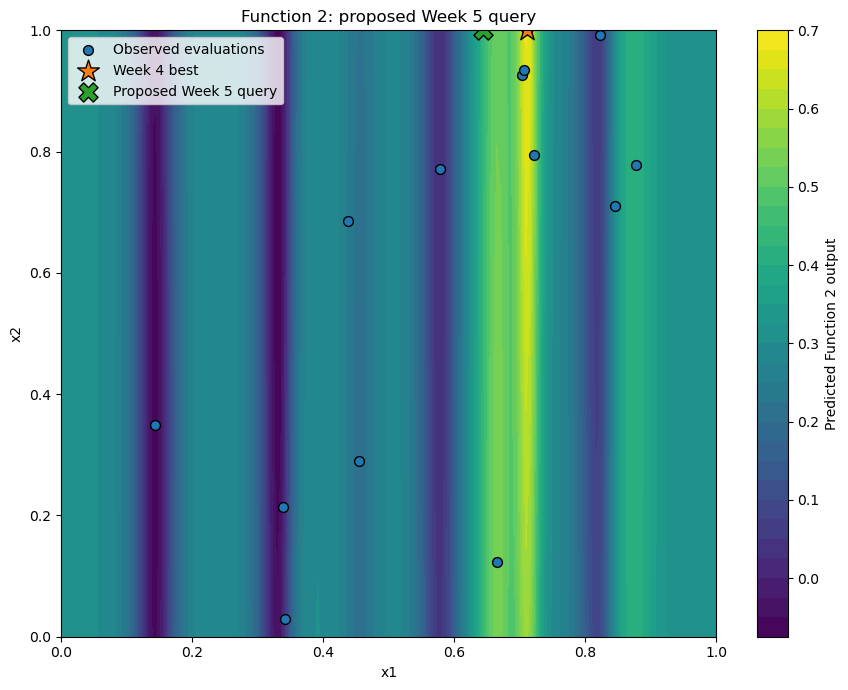

In [2]:
# ------------------------------------------------------------
# 8. Plot the Function 2 Week 5 proposal
# ------------------------------------------------------------

grid_size = 180

x1_values = np.linspace(0, 1, grid_size)
x2_values = np.linspace(0, 1, grid_size)

X1_grid, X2_grid = np.meshgrid(
    x1_values,
    x2_values
)

grid_points = np.column_stack([
    X1_grid.ravel(),
    X2_grid.ravel()
])

grid_mean, grid_std = gp.predict(
    grid_points,
    return_std=True
)

grid_mean = grid_mean.reshape(X1_grid.shape)

plt.figure(figsize=(9, 7))

contour = plt.contourf(
    X1_grid,
    X2_grid,
    grid_mean,
    levels=30
)

plt.colorbar(
    contour,
    label="Predicted Function 2 output"
)

plt.scatter(
    X[:, 0],
    X[:, 1],
    s=50,
    edgecolor="black",
    label="Observed evaluations"
)

plt.scatter(
    week4_x[0, 0],
    week4_x[0, 1],
    marker="*",
    s=270,
    edgecolor="black",
    label="Week 4 best"
)

plt.scatter(
    week5_query[0],
    week5_query[1],
    marker="X",
    s=190,
    edgecolor="black",
    label="Proposed Week 5 query"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Function 2: proposed Week 5 query")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()